<a href="https://colab.research.google.com/github/Aravindr017/CNN_Car-classification/blob/Aravind-Workspace/Model/Car_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import numpy as np
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical
from PIL import Image
from keras.regularizers import l2

# Reading Dataset

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
directory = "/content/drive/MyDrive/ICT - Ai Ml/CNN_Parallel Project/Dataset/dataset/DATA"
categories = ['Golf','bmw serie 1','chevrolet spark','chevroulet aveo','clio','duster','hyundai i10','hyundai tucson','logan','megane','mercedes class a','nemo citroen','octavia','picanto','polo','sandero','seat ibiza','symbol','toyota corolla','volkswagen tiguan']

# EDA and Preprocessing

In [9]:
img_size = 64
data = []
labels = []

# Iterate over each category
for category in categories:
    category_dir = os.path.join(directory, category)

    # Iterate over each file in the category directory
    for filename in os.listdir(category_dir):
        # Check if the file is an image (you might want to add more sophisticated checks)
        if filename.endswith(".jpg") or filename.endswith(".png"):
            # Load image with error handling
            try:
                image_path = os.path.join(category_dir, filename)
                image = Image.open(image_path)

                # Resize image and convert to grayscale
                image = image.resize((img_size, img_size)).convert('L')

                # Convert image to numpy array
                image_array = np.array(image)

                # Append the image array to the data list
                data.append(image_array)

                # Append the label corresponding to the category
                labels.append(categories.index(category))  # Use index as label (assuming categories are ordered)
            except Exception as e:
                print(f"Error loading image {filename}: {e}")

# Convert data and labels to numpy arrays
data = np.array(data)
labels = np.array(labels)

# Reshape data to have a single channel for grayscale images (if needed)
data = data.reshape(-1, img_size, img_size, 1)

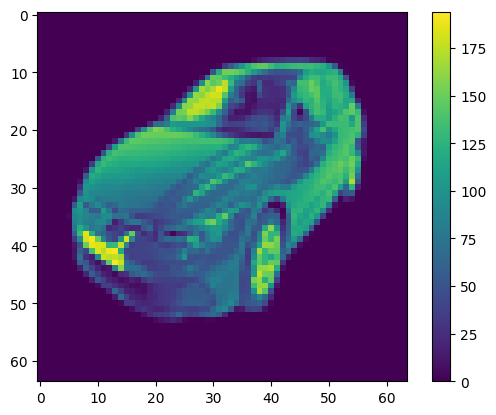

In [10]:
plt.figure()
plt.imshow(data[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [11]:
data = np.array(data)
labels = np.array(labels)

In [12]:
data = data.astype('float32') / 255.0


# Model building

In [13]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)


In [14]:
print(y_train)


[18  9 15 ...  7  5 19]


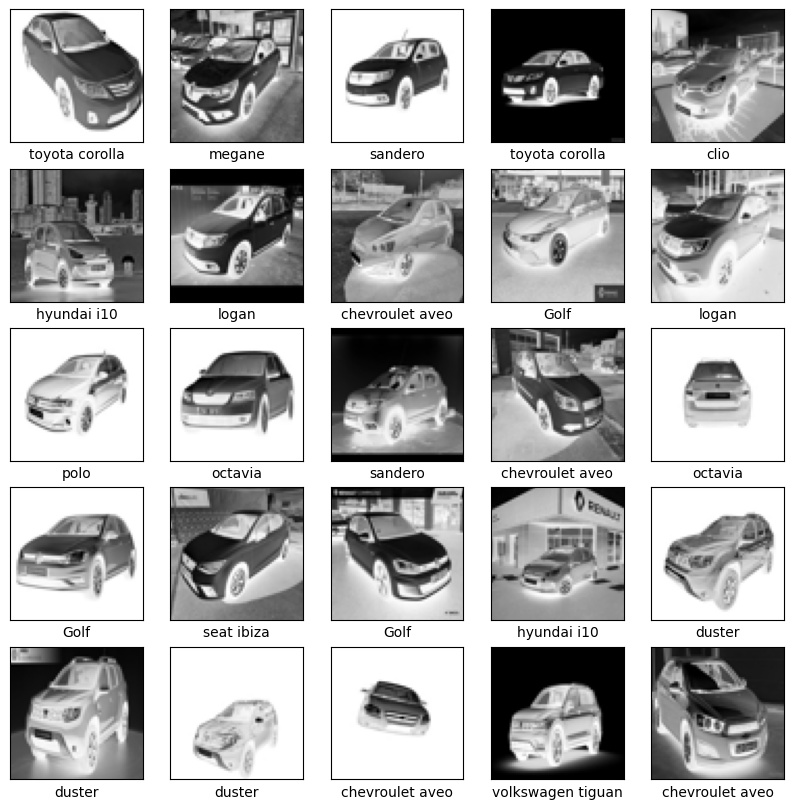

In [15]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(categories[y_train[i]])
plt.show()

In [16]:
# Define the model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(categories), activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,204 (2.61 MB)

 Trainable params: 685,204 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Fit the model
history = model.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2)

Epoch 1/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.1116 - loss: 2.9227 - val_accuracy: 0.1371 - val_loss: 2.8682
Epoch 2/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1464 - loss: 2.7941 - val_accuracy: 0.1718 - val_loss: 2.6727
Epoch 3/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2676 - loss: 2.4468 - val_accuracy: 0.2780 - val_loss: 2.4294
Epoch 4/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4130 - loss: 1.9587 - val_accuracy: 0.3436 - val_loss: 2.1453
Epoch 5/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6010 - loss: 1.3642 - val_accuracy: 0.4305 - val_loss: 1.9926
Epoch 6/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7401 - loss: 0.8750 - val_accuracy: 0.5232 - val_loss: 1.6916
Epoch 7/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8802 - loss: 0.4505 - val_accuracy: 0.5907 - val_loss: 1.9139
Epoch 8/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9382 - loss: 0.2241 - val_accuracy: 0.5695 

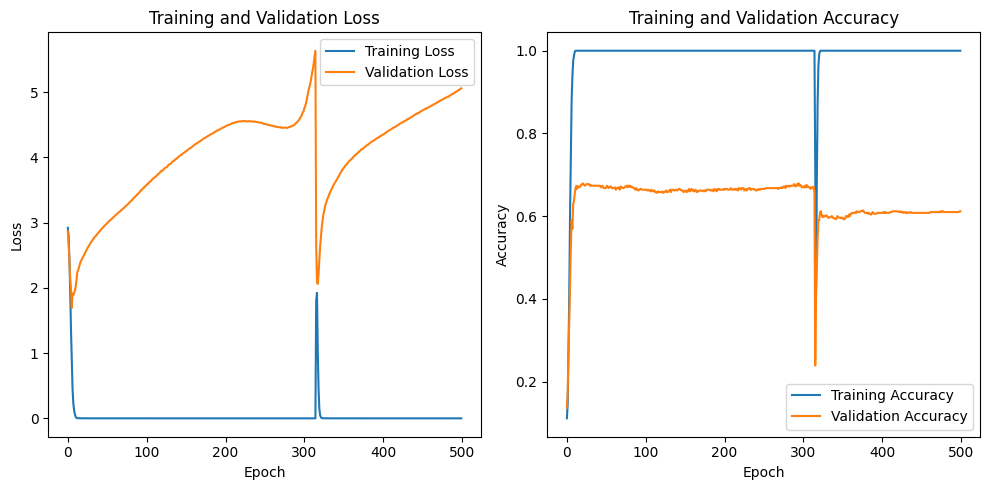

In [20]:
# Get training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Get training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [21]:
# Define the model with drop out
model2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Adding dropout after the first pooling layer
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Adding dropout after the second pooling layer
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Adding dropout after the third pooling layer
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),   # Adding dropout before the output layer
    Dense(len(categories), activation='softmax')
])

In [22]:
# Compile the model
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [23]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,204 (2.61 MB)

 Trainable params: 685,204 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Fit the model
history = model2.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2)

Epoch 1/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.0821 - loss: 2.9685 - val_accuracy: 0.1120 - val_loss: 2.9468
Epoch 2/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1000 - loss: 2.9228 - val_accuracy: 0.1120 - val_loss: 2.8736
Epoch 3/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1217 - loss: 2.8767 - val_accuracy: 0.1660 - val_loss: 2.8012
Epoch 4/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1589 - loss: 2.7672 - val_accuracy: 0.1795 - val_loss: 2.7004
Epoch 5/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1812 - loss: 2.6692 - val_accuracy: 0.2085 - val_loss: 2.6028
Epoch 6/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2101 - loss: 2.5658 - val_accuracy: 0.2355 - val_loss: 2.5011
Epoch 7/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2386 - loss: 2.4529 - val_accuracy: 0.2934 - val_loss: 2.4119
Epoch 8/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2758 - loss: 2.3306 - val_accuracy: 0.334

In [25]:
# Evaluate the model on the test set
test_loss, test_accuracy = model2.evaluate(X_test, y_test)
print("Loss:", test_loss)
print("Accuracy:", test_accuracy)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7944 - loss: 1.7920
Loss: 1.792028784751892
Accuracy: 0.7944358587265015


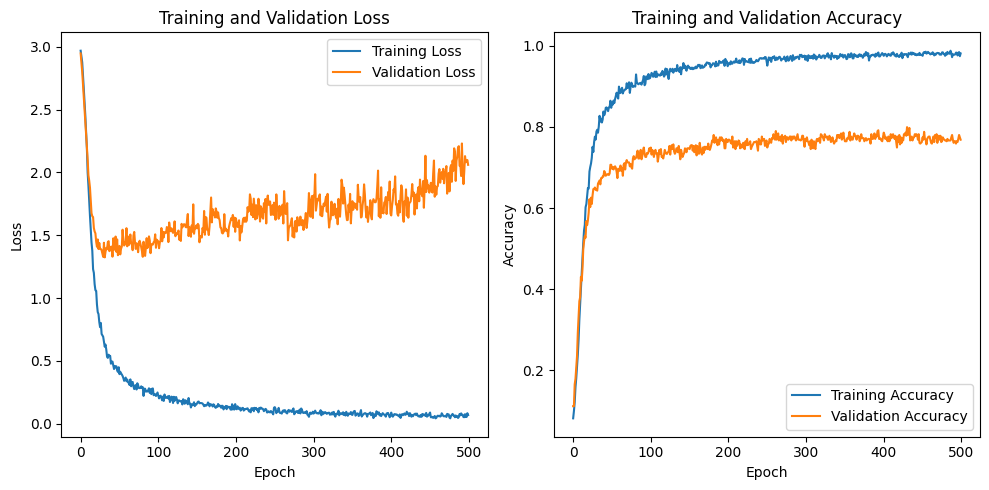

In [26]:
# Get training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Get training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [27]:
def plot_image(i, predictions_array, true_label, img, class_names):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                         100*np.max(predictions_array),
                                         class_names[true_label]),
               color=color)

def plot_value_array(i, predictions_array, true_label, class_names):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(len(class_names)))
    plt.yticks([])
    thisplot = plt.bar(range(len(class_names)), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

In [28]:
predictions = model.predict(X_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


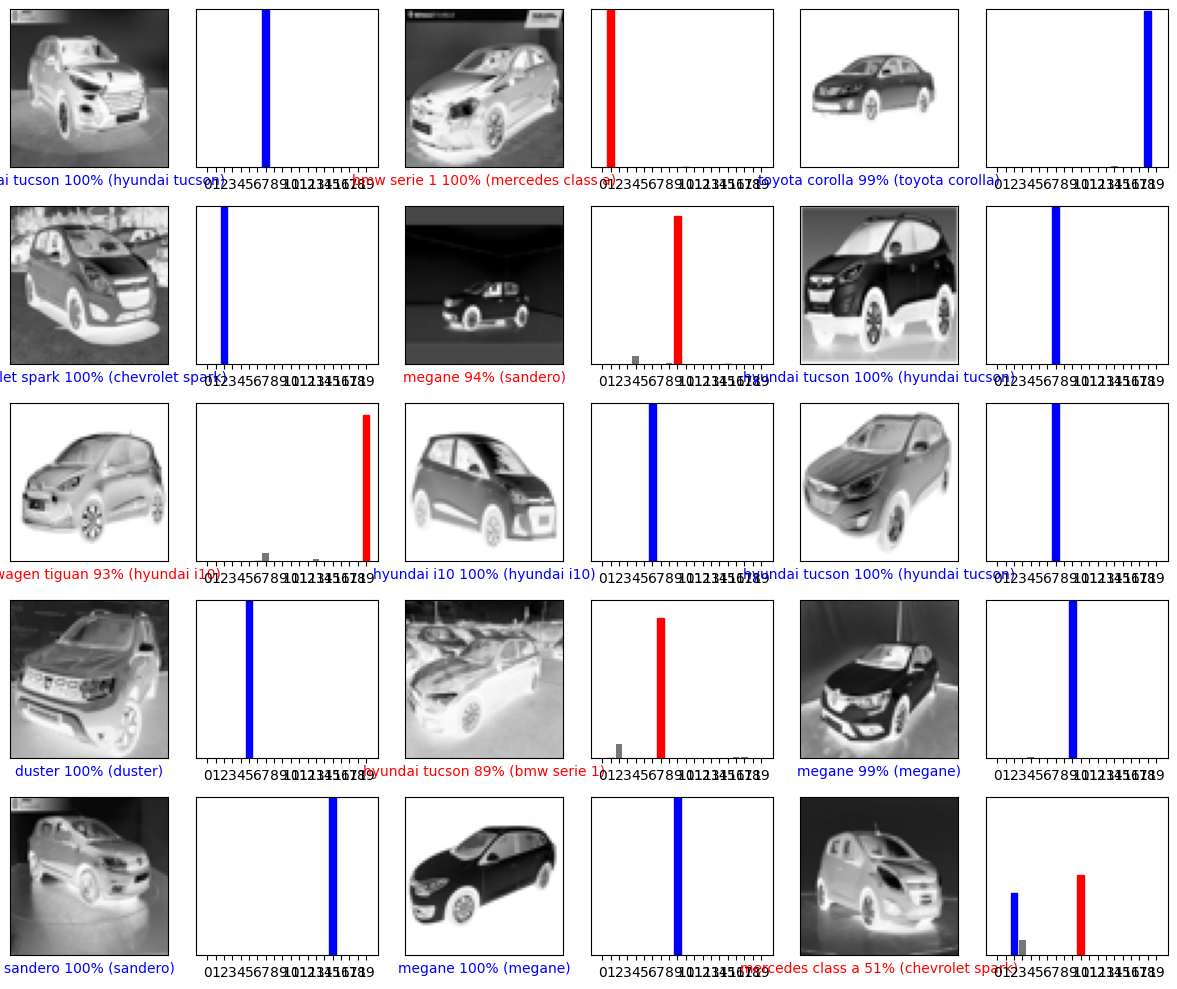

In [29]:
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i],y_test, X_test, categories)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions[i],  y_test, categories)
plt.tight_layout()
plt.show()

In [30]:
predictions = model2.predict(X_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


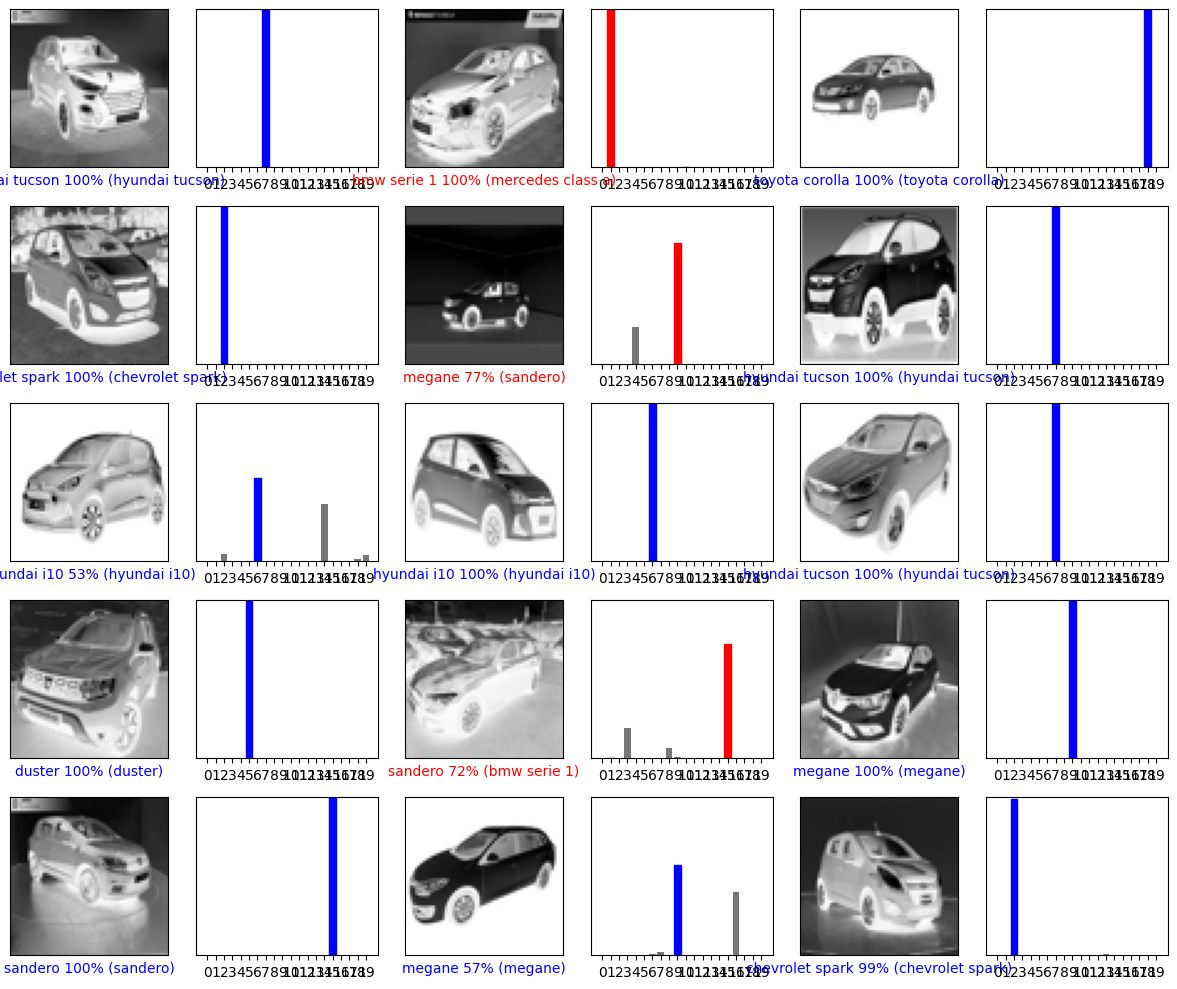

In [31]:
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i],y_test, X_test, categories)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions[i],  y_test, categories)
plt.tight_layout()
plt.show()

In [32]:
# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

In [33]:
# Define the model
model1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(categories), activation='softmax')
])

In [34]:
# Compile the model
model1.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

In [35]:
# Train the model with early stopping
history = model1.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.0918 - loss: 2.9252 - val_accuracy: 0.1158 - val_loss: 2.8262
Epoch 2/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1488 - loss: 2.7556 - val_accuracy: 0.1718 - val_loss: 2.6557
Epoch 3/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2594 - loss: 2.4442 - val_accuracy: 0.2664 - val_loss: 2.4202
Epoch 4/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4217 - loss: 1.9444 - val_accuracy: 0.3514 - val_loss: 2.2136
Epoch 5/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5831 - loss: 1.3726 - val_accuracy: 0.4459 - val_loss: 1.9496
Epoch 6/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7551 - loss: 0.8779 - val_accuracy: 0.5135 - val_loss: 1.8635
Epoch 7/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8652 - loss: 0.4877 - val_accuracy: 0.5714 - val_loss: 1.7861
Epoch 8/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9362 - loss: 0.2428 - val_accuracy: 0.5927 -

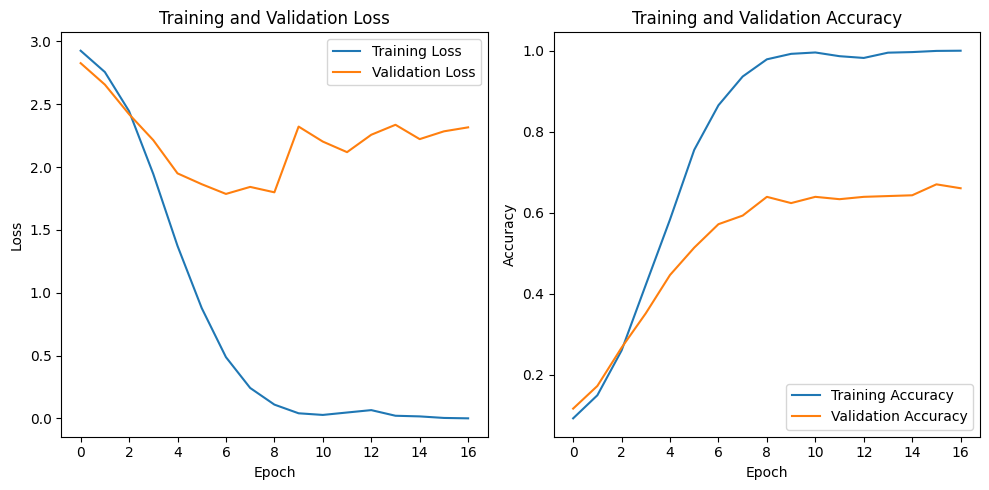

In [36]:
# Get training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Get training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
# Evaluate the model on the test set
test_loss, test_accuracy = model1.evaluate(X_test, y_test)
print("Loss:", test_loss)
print("Accuracy:", test_accuracy)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6569 - loss: 2.2744
Loss: 2.274439811706543
Accuracy: 0.656877875328064


###Padding

In [38]:
# Define the model with padding='same'
model3 = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_size, img_size, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(categories), activation='softmax')
])

In [39]:
# Compile the model
model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [40]:
# Train the model with early stopping
history = model3.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2)

Epoch 1/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.0729 - loss: 2.9622 - val_accuracy: 0.1042 - val_loss: 2.9017
Epoch 2/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0976 - loss: 2.9257 - val_accuracy: 0.1023 - val_loss: 2.8798
Epoch 3/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1188 - loss: 2.8515 - val_accuracy: 0.1448 - val_loss: 2.7695
Epoch 4/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1614 - loss: 2.7614 - val_accuracy: 0.1911 - val_loss: 2.6924
Epoch 5/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1889 - loss: 2.6243 - val_accuracy: 0.1988 - val_loss: 2.5503
Epoch 6/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2367 - loss: 2.4624 - val_accuracy: 0.2471 - val_loss: 2.4409
Epoch 7/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2923 - loss: 2.2624 - val_accuracy: 0.2780 - val_loss: 2.3280
Epoch 8/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3691 - loss: 2.0417 - val_accuracy: 0.3533 - 

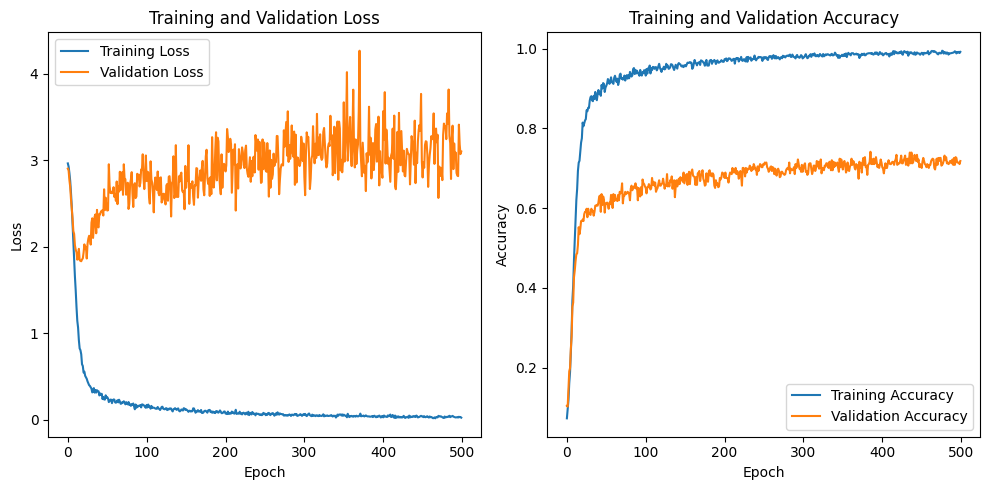

In [41]:
# Get training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Get training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
# Evaluate the model on the test set
test_loss, test_accuracy = model3.evaluate(X_test, y_test)
print("Loss:", test_loss)
print("Accuracy:", test_accuracy)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7403 - loss: 2.6443
Loss: 2.644293785095215
Accuracy: 0.7403400540351868


In [43]:
# Define the model with drop out
model4 = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_size, img_size, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Adding dropout after the first pooling layer
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Adding dropout after the second pooling layer
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Adding dropout after the third pooling layer
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),   # Adding dropout before the output layer
    Dense(len(categories), activation='softmax')
])

In [44]:
# Compile the model
model4.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [45]:
# Train the model with early stopping
history = model4.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2)

Epoch 1/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - accuracy: 0.0787 - loss: 2.9613 - val_accuracy: 0.0772 - val_loss: 2.9423
Epoch 2/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0966 - loss: 2.9210 - val_accuracy: 0.1274 - val_loss: 2.8653
Epoch 3/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1203 - loss: 2.8691 - val_accuracy: 0.1429 - val_loss: 2.7835
Epoch 4/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1633 - loss: 2.7376 - val_accuracy: 0.1660 - val_loss: 2.6655
Epoch 5/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1758 - loss: 2.6769 - val_accuracy: 0.2027 - val_loss: 2.6075
Epoch 6/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1961 - loss: 2.6026 - val_accuracy: 0.2259 - val_loss: 2.5039
Epoch 7/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2570 - loss: 2.4110 - val_accuracy: 0.2664 - val_loss: 2.3646
Epoch 8/500
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3208 - loss: 2.2398 - val_accuracy: 0.3

In [46]:
# Evaluate the model on the test set
test_loss, test_accuracy = model4.evaluate(X_test, y_test)
print("Loss:", test_loss)
print("Accuracy:", test_accuracy)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7805 - loss: 1.7951
Loss: 1.7950854301452637
Accuracy: 0.7805255055427551


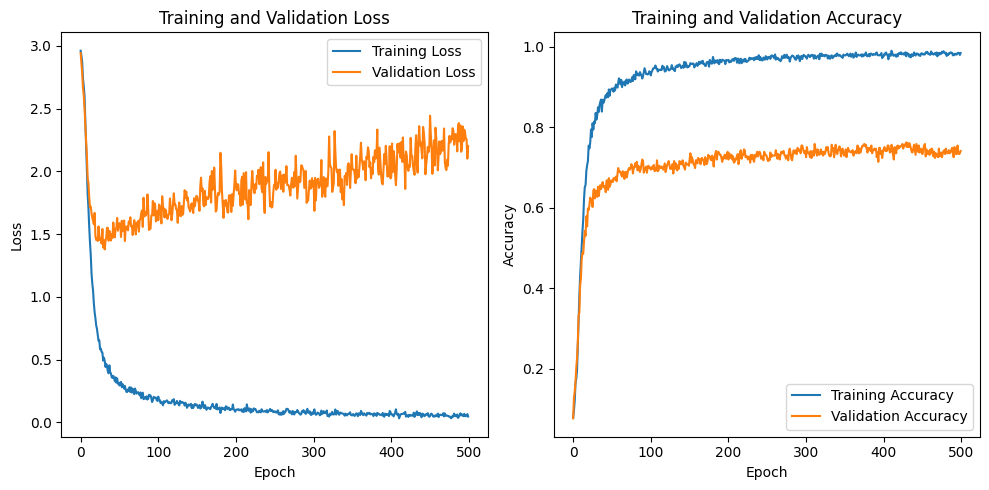

In [47]:
# Get training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Get training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()